
## How to Use the Notebooks

To run these notebooks, follow these steps:


### 1. Install **`gdal`** Package
Installing `gdal` via `pip` may fail. Therefore, we recommend using conda to install it:
```bash
conda install gdal -c conda-forge
```

### 2. Install **`polsartools`** Package

Before running the notebooks, you'll need to install the core **`polsartools`** package. 

**Option A:** Install from PyPI `pip` (stable release)

```bash
pip install polsartools
```

**Option B:** Install from conda (stable release)

```bash
conda install polsartools -c bnarayanarao
```


**Option C:**  Install the latest version from GitHub (if you need recent updates or fixes)

```bash
pip install git+https://github.com/Narayana-Rao/polsartools.git#egg=polsartools
```
> **Note:** If you encounter a `"module not found"` error or require newer features, prefer the GitHub installation (Option C).

### 3. Verify the Installation

After successfully installing `polsartools`, you can verify it by importing the package:

```bash
import polsartools as pst
```

If this runs without errors, you're ready to explore and run the notebooks.




In [1]:
""" 

import required packages

"""
import os
import matplotlib.pyplot as plt
import numpy as np
import polsartools as pst
    

In [2]:
""" 

Function to display images

"""

def plot_images(*filenames, lower_percentile=2, upper_percentile=98, max_cols=4):
    def compute_vmin_vmax(data):
        data_no_nan = data[np.isfinite(data)]
        vmin = np.percentile(data_no_nan, lower_percentile)
        vmax = np.percentile(data_no_nan, upper_percentile)
        return vmin, vmax

    num_images = len(filenames)

    if num_images == 1:
        # Single image case
        data = pst.read_rst(filenames[0])
        data[data==0]=np.nan
        vmin, vmax = compute_vmin_vmax(data)

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(data, vmin=vmin, vmax=vmax)
        ax.set_title(os.path.basename(filenames[0]))
        fig.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        # Multiple image case
        ncols = min(max_cols, num_images)
        nrows = int(np.ceil(num_images / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
        axes = np.array(axes).reshape(-1)  # Flatten in case it's a 2D grid

        for i, filename in enumerate(filenames):
            data = pst.read_rst(filename)
            data[data==0]=np.nan
            vmin, vmax = compute_vmin_vmax(data)
            ax = axes[i]
            im = ax.imshow(data, vmin=vmin, vmax=vmax)
            ax.set_title(os.path.basename(filename))
            fig.colorbar(im, ax=ax)

        for j in range(num_images, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()


#### 1. Extract multilooked C2 matrix from ALOS-2 WBD data
##### using **`polsartools.import_alos2_wbd_l11`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/sensors/alos2.html#wbd-l1-1-import-alos2-wbd-l11) or run `print(polsartools.import_alos2_wbd_l11.__.doc__)`



In [3]:
inFolder =r"../data/ALOS2_WBD"


# The following function extracts a multilooked C2 matrix from ALOS-2 FBD data. 
# Provide path to the ALOS-2 extracted folder

pst.import_alos2_wbd_l11(inFolder,azlks=25,rglks=5,
                  mat='C2', # matrix type C2/Sxy
                  fmt='tif', # output format tif//bin
                  cog=False, ovr=[2, 4, 8, 16], # COG prameters
                  comp=False, # Tiff compression (optional)
                  out_dir=None, #path to out_dir (optional)
                 )

Extracting swath 1 ...


Progress: 100%|████████████████████████████████████████████████████████████| 2770/2770 [00:15<00:00, 178.38block/s]


Saved file ../data/ALOS2_WBD/C2/C11.tif
Saved file ../data/ALOS2_WBD/C2/C12_real.tif
Saved file ../data/ALOS2_WBD/C2/C12_imag.tif
Saved file ../data/ALOS2_WBD/C2/C22.tif
Execution time for convert_S: 16.00 seconds
Execution time for import_alos2_wbd_l11: 01:33 (min:sec)


#### 2. Speckle filtering using polarimetric refined-Lee filter

In [4]:
c2Folder = os.path.join(inFolder,'C2')
window_size = 3
pst.filter_refined_lee(c2Folder,win=window_size,
          fmt='tif', # output format tif//bin
        sub_dir=True, # creates a sub directory with filtered data
      cog=False, ovr=[2, 4, 8, 16], # COG prameters
      comp=False, # Tiff compression (optional)
        )

Progress: 100%|█████████████████████████████████████████████████████████████████| 22/22 [00:01<00:00, 21.88block/s]


Saved file ../data/ALOS2_WBD/rlee_3x3/C2/C11.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/C12_real.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/C12_imag.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/C22.tif
Execution time for filter_refined_lee: 1.00 seconds


#### 3. Generate a quick look RGB from C2 matrix

RGB image saved as ../data/ALOS2_WBD/rlee_3x3/C2/RGB4.png
Execution time for rgb_dp: 2.00 seconds


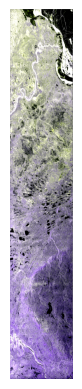

In [5]:

c2Folder = os.path.join(inFolder,'rlee_3x3','C2')
# pst.rgb_dp(c2Folder,type=1)
# pst.rgb_dp(c2Folder,type=2)
# pst.rgb_dp(c2Folder,type=3)
pst.rgb_dp(c2Folder,type=4)

#### 4. Generating some polarimetric parameters from C2 matrix

##### 4.1 Barakat Degree of polarization 
##### using `polsartools.dopdp` function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/DOP_dp.html) or run `print(polsartools.dopdp.__.doc__)`


In [6]:

pst.dop_dp(c2Folder)


Progress: 100%|████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 193.47block/s]

Saved file ../data/ALOS2_WBD/rlee_3x3/C2/dopdp.tif
Execution time for dop_dp: 0.00 seconds


##### Preview the output

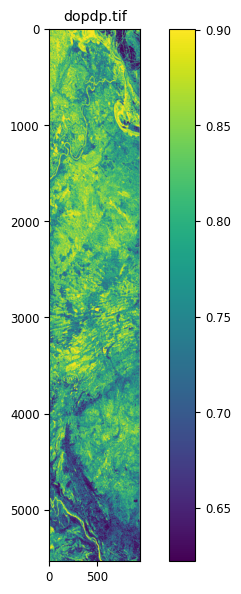

In [7]:
plot_images(c2Folder+'/dopdp.tif', lower_percentile=2, upper_percentile=98, max_cols=4)



##### 4.2. Entropy-Alpha (H/α) parameters 
##### using **`polsartools.h_alpha_dp`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/halphadxp.html) or run `print(polsartools.h_alpha_dp.__.doc__)`


In [8]:
pst.h_alpha_dp(c2Folder)


Progress: 100%|█████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 22.68block/s]


Saved file ../data/ALOS2_WBD/rlee_3x3/C2/Hdp.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/alphadp.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/e1_norm.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/e2_norm.tif
Execution time for h_alpha_dp: 1.00 seconds


##### Preview the output

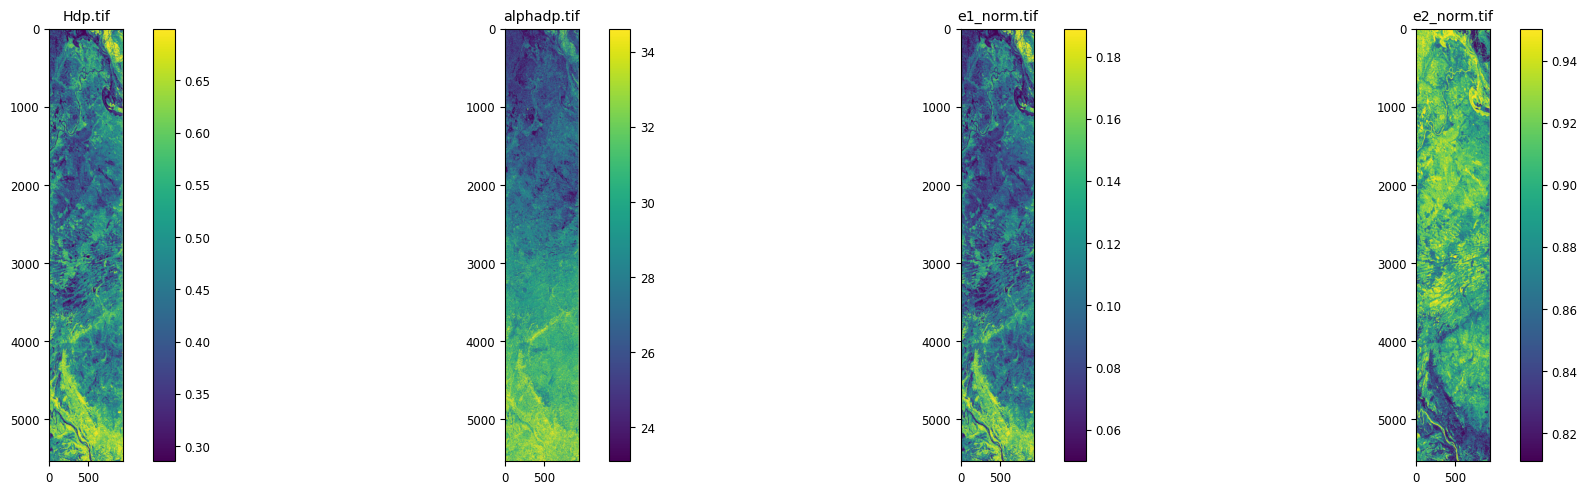

In [9]:

plot_images(c2Folder + '/Hdp.tif',
            c2Folder + '/alphadp.tif', 
            c2Folder + '/e1_norm.tif', 
            c2Folder + '/e2_norm.tif', 
            lower_percentile=2, upper_percentile=98, max_cols=4)


##### Plot Entropy-Alpha plot for dual-pol
##### using **`polsartools.halpha_plot_dp`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/halpha_plot_dp.html) or run `print(polsartools.halpha_plot_dp.__.doc__)`

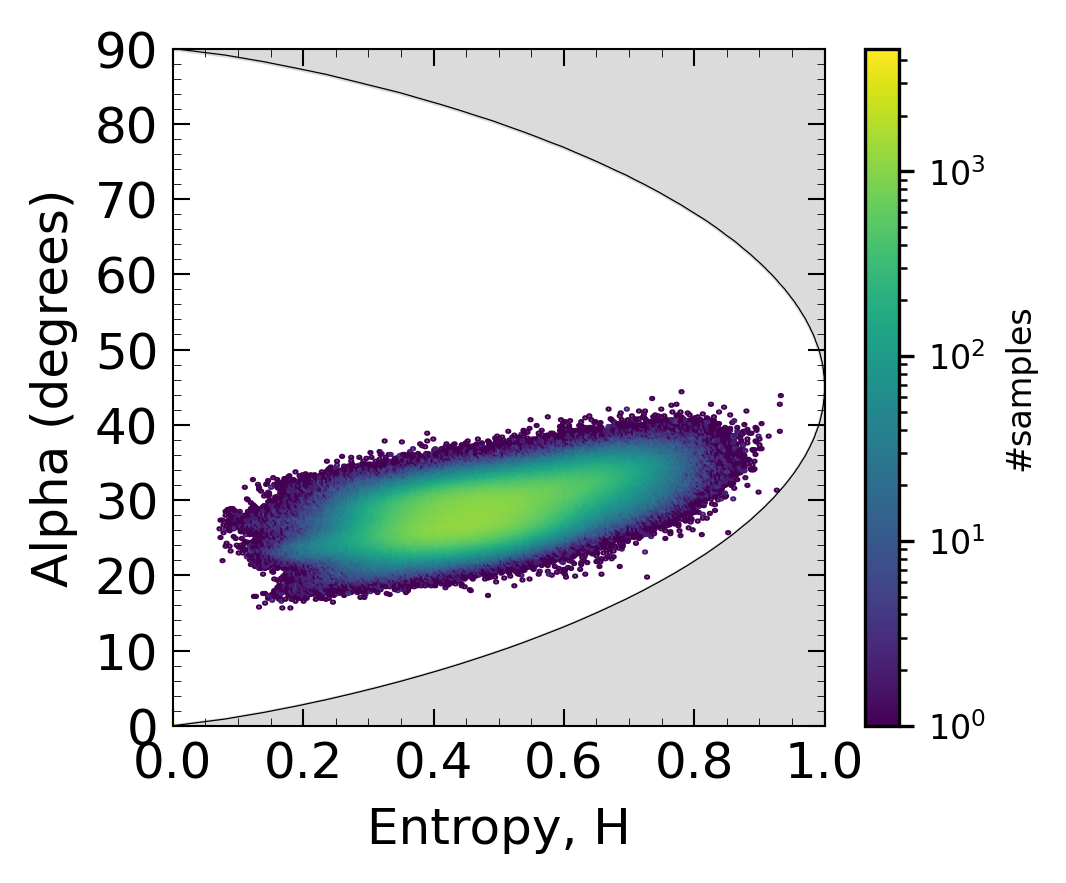

In [15]:
hFile = c2Folder + '/Hdp.tif'
alphaFile = c2Folder + '/alphadp.tif'

pst.plot_h_alpha_dp(hFile,alphaFile,
                  # path=None, path to save plot as .png
                   # cmap='viridis',
                   # colorbar=True, 
                   norm='log', 
                   # grey_region=True, 
                   # gridsize=300
                  )

##### 4.3. Shannon Entropy parameters (SE is the sum of contributions from intensity (SEI) and polarimetry (SEP))
##### using **`polsartools.shannon_h_dp`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/shannon_h_dp.html) or run `print(polsartools.shannon_h_dp.__.doc__)`

In [11]:
pst.shannon_h_dp(c2Folder,win = 3)

Progress: 100%|█████████████████████████████████████████████████████████████████| 22/22 [00:01<00:00, 20.58block/s]


Saved file ../data/ALOS2_WBD/rlee_3x3/C2/H_Shannon.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/HI_Shannon.tif
Saved file ../data/ALOS2_WBD/rlee_3x3/C2/HP_Shannon.tif
Execution time for shannon_h_dp: 1.00 seconds


##### Preview the output

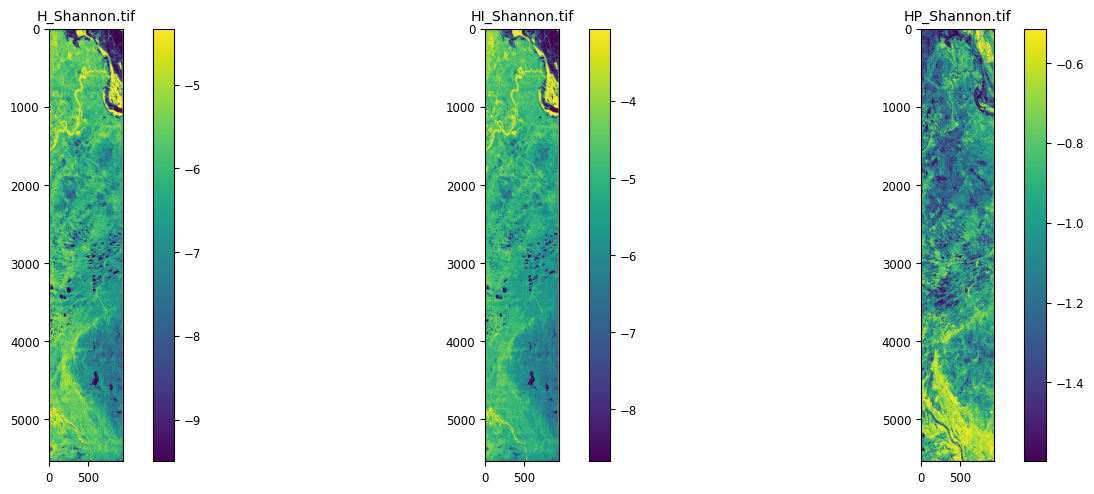

In [12]:

plot_images(c2Folder + '/H_Shannon.tif',
            c2Folder + '/HI_Shannon.tif',
            c2Folder + '/HP_Shannon.tif',
            lower_percentile=2, upper_percentile=98, max_cols=4)



##### 4.4. vegetation indices, Radar vegetation index (RVI), Dual-pol Radar Vegetation Index (DpRVI)

##### using **`polsartools.rvidp`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/RVI_dp.html) or run `print(polsartools.rvidp.__.doc__)`

##### using **`polsartools.dprvi`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/RVI_dp.html) or run `print(polsartools.dprvi.__.doc__)`




In [13]:

pst.rvi_dp(c2Folder)

pst.dprvi(c2Folder)


Progress: 100%|████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 283.01block/s]

Saved file ../data/ALOS2_WBD/rlee_3x3/C2/rvidp.tif
Execution time for rvi_dp: 0.00 seconds



Progress: 100%|█████████████████████████████████████████████████████████████████| 22/22 [00:00<00:00, 90.95block/s]

Saved file ../data/ALOS2_WBD/rlee_3x3/C2/dprvi.tif
Execution time for dprvi: 0.00 seconds


##### Preview the output

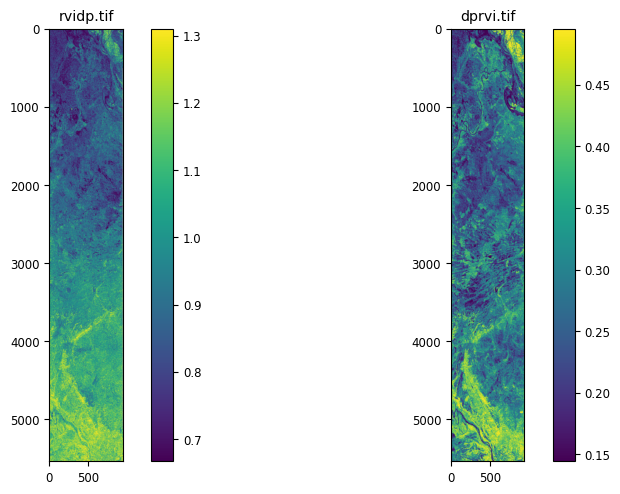

In [14]:


plot_images(c2Folder + '/rvidp.tif',
            c2Folder + '/dprvi.tif',
            lower_percentile=2, upper_percentile=98, max_cols=4)

